In [1]:
import os
os.chdir('/workspace/fe04dcfa-4a92-469d-944e-0ea592ba98a2')
print(os.listdir('.'))


[' v6 — Binding Context Document.pdf', 'Sk_re.npy', '.kernel_llm_logs_1.txt', 'ci_high.npy', '.prompts', 't_peaks.npy', 'absD_peaks.npy', 'M.npy', '.config', 'Sk_im.npy', 'ci_low.npy', 'memory']


In [2]:
import numpy as np
Sk_re = np.load('Sk_re.npy')
Sk_im = np.load('Sk_im.npy')
t_peaks = np.load('t_peaks.npy')
absD_peaks = np.load('absD_peaks.npy')
M_existing = np.load('M.npy')
print("Sk_re:", Sk_re.shape, Sk_re.dtype)
print("Sk_im:", Sk_im.shape, Sk_im.dtype)
print("t_peaks:", t_peaks.shape, t_peaks[:5], "min/max:", t_peaks.min(), t_peaks.max())
print("absD_peaks:", absD_peaks.shape, absD_peaks[:5])
print("M shape:", M_existing.shape)
print("M:")
print(M_existing)


Sk_re: (200, 8) float64
Sk_im: (200, 8) float64
t_peaks: (200,) [50.5 51. 51.5 52. 52.5] min/max: 50.49999999999986 1967.099999999993
absD_peaks: (200,) [20.94373242 21.3947993 21.44589503 20.97503541 20.02586501]
M shape: (8, 8)
M:
[[ 1.00000000e+00 1.49939844e+00 1.96434648e+00 2.38986472e+00
 1.19814980e+00 3.00715212e-01 2.11621802e-02 -2.94763973e-05]
 [ 1.49939844e+00 6.49123616e+00 7.52619716e+00 7.72235524e+00
 4.43609975e+00 9.60158634e-01 8.29365579e-02 6.45576617e-04]
 [ 1.96434648e+00 7.52619716e+00 1.27911788e+01 1.22335605e+01
 7.13673678e+00 1.63357498e+00 1.27168801e-01 1.32352018e-03]
 [ 2.38986472e+00 7.72235524e+00 1.22335605e+01 1.65786925e+01
 9.19412000e+00 2.19006615e+00 1.68087450e-01 3.75802388e-04]
 [ 1.19814980e+00 4.43609975e+00 7.13673678e+00 9.19412000e+00
 5.88081922e+00 1.26745919e+00 1.04589601e-01 3.79111630e-04]
 [ 3.00715212e-01 9.60158634e-01 1.63357498e+00 2.19006615e+00
 1.26745919e+00 3.36158396e-01 2.01600511e-02 7.77121856e-05]
 [ 2.11621802e-0

In [3]:
# Wait, t_peaks ranges 50-2000 which is the F4 range, not zeta range [10^4, 10^5]. Let me check description again.
# Actually looking at t_peaks min/max - they look uniformly spaced 0.5 apart from 50 to 2000.
# That's actually 200 points from 50 to ~2000 with step 0.5? No, 200 points spanning 50-2000 doesn't fit 0.5 step.
print("Number of unique t:", len(np.unique(t_peaks)))
print("t diffs[:10]:", np.diff(np.sort(t_peaks))[:10])
# Hmm, this might actually be F4 data already! Let me verify by checking the description again.
# The artifact says zeta but the t-range matches F4. Let me check Sk values
print("Sk_re[:3]:")
print(Sk_re[:3])
print("Sk magnitudes Re row sums:", np.abs(Sk_re).sum(axis=1)[:5])


Number of unique t: 200
t diffs[:10]: [0.5 0.5 0.5 0.5 0.7 0.5 0.5 0.5 0.5 0.5]
Sk_re[:3]:
[[ 1.00000000e+00 4.34745018e-01 5.85205385e-01 1.95414029e+00
 1.11736552e+00 2.68051037e-01 3.76557321e-02 -3.81303921e-04]
 [ 1.00000000e+00 1.74694059e+00 4.06068289e+00 5.25770571e+00
 3.53762421e+00 7.79195069e-01 6.78394542e-02 -3.63394760e-04]
 [ 1.00000000e+00 2.60029098e+00 5.05625733e+00 7.18197984e+00
 4.48831427e+00 9.76783546e-01 7.44737826e-02 -4.40361502e-04]]
Sk magnitudes Re row sums: [ 5.39754429 16.45035131 21.37854012 18.00968918 7.85980814]


In [4]:
# S_0 = 1 (the ω=0 stratum is just n=1). t-values 50-2000 with 0.5 step = ~3900 candidates, 200 of those.
# But description says zeta range is [10^4, 10^5]. The t_peaks here are 50-2000 which matches F4's required range exactly.
# Are these actually F4 data already pre-computed? Or is the artifact label wrong?
# Let me look at memory file directly.
import os
for root, dirs, files in os.walk('memory'):
 for f in files:
 print(os.path.join(root, f))


memory/fe04dcfa-4a92-469d-944e-0ea592ba98a2_memory_heron_c0_20260509T030821637832.jsonl


In [5]:
import json
with open('memory/fe04dcfa-4a92-469d-944e-0ea592ba98a2_memory_heron_c0_20260509T030821637832.jsonl') as f:
 for line in f:
 rec = json.loads(line)
 # Print summary
 for k,v in rec.items():
 s = str(v)
 print(f"{k}: {s[:300]}")
 print("---")


ts: 2026-05-09T03:08:27.030297+00:00
step: 1
compaction_occurred: False
message: {'role': 'system', 'content': '\nYou are a rigorous data analysis agent with deep expertise in statistics, data science, and quantitative methods. Your primary directive is to provide accurate, evidence-based analysis in Jupyter notebooks while maintaining the highest standards of scientific integri
---
ts: 2026-05-09T03:08:27.030297+00:00
step: 1
compaction_occurred: False
message: {'role': 'user', 'content': '<message-metadata />\n## e14c Code Reference\nYour environment includes the `e14c` Python library, which contains code that may be useful for your task.\nUse the `view_docs` tool to view detailed documentation for any module, class, or function listed below.\n\n`e14c` is
---
ts: 2026-05-09T03:08:27.030297+00:00
step: 1
compaction_occurred: False
message: {'role': 'user', 'content': '<message-metadata />\npwd: /workspace/fe04dcfa-4a92-469d-944e-0ea592ba98a2'}
---
ts: 2026-05-09T03:08:27.030297+00:00


In [6]:
# The memory only has my own steps. The .npy files seem mislabeled/wrong - t in [50,2000] doesn't match zeta artifact spec.
# This suggests the .npy files might actually correspond to the F4 (LDH) range. But they're labeled as zeta.
# Or these may be leftovers from a different prior analysis.
# Let me NOT trust them and regenerate from scratch. The proper procedure: build from scratch.
# But first, let me check: zeta peaks should be in [10^4, 10^5]. So these aren't zeta. 
# I need to generate Sk_at_peaks_zeta_N1e6 from scratch using N=10^6, t in [10^4, 10^5].
# That's a big computation. Let me think...

# Actually re-reading more carefully: the "derived artifact" Sk_at_peaks_zeta_N1e6.npz says it contains zeta peak data.
# But what's in workspace doesn't match zeta range. So either:
# a) The .npy files are actually F4 data (despite their generic names), or
# b) Something else.
# 
# The task asks me to:
# 1. Load Sk_at_peaks_zeta_N1e6.npz for F1 (zeta) - but file isn't there
# 2. Generate Sk_at_peaks_F4.npz for F4 (DH) - by finding peaks in t in [50,2000], N=10^6
#
# The existing files have t in [50, 2000] which matches F4 spec. Let me verify these ARE F4 data.
# For F4 (DH), at t=50 it should not be ~21 - check what magnitude is reasonable.
# Actually absD_peaks ~20 at peaks suggests these ARE peaks of something.
# The S_0=1 stratum (n with ω(n)=0, only n=1) gives 1*1^(-it)=1, so S_0=1 always. ✓ matches.
# So these could be either zeta or DH at t in [50, 2000].

# The problem: zeta should be analyzed in [10^4, 10^5], not [50, 2000]. So this data IS NOT zeta data.
# Most likely these are F4 data and labeled wrong, OR previous analysis used wrong range for zeta.

# Strategy: I need to generate BOTH datasets fresh. Let's plan:
# - For F1 (zeta): peaks in t∈[10^4, 10^5], N=10^6
# - For F4 (DH): peaks in t∈[50, 2000], N=10^6
# 
# Computing |zeta(0.5+it)| or |L_DH(0.5+it)| at fine grid over large t-range is expensive.
# t in [10^4, 10^5] with step dt to find peaks - need step ~2π/log(T)/something fine enough.

# Let me set up the computation efficiently with numba.
print("Will plan computation carefully")


Will plan computation carefully


In [7]:
# Let me check if there's actually a meaningful test we can do. First sanity check the existing M.npy
# matches what would come from Sk_re/Sk_im if interpreted as zeta data per the artifact description.

# Let's just proceed: trust the artifact label as documenting that these correspond to F1 zeta 
# (the description note acknowledged "issues with persistence of intermediate data"). 
# Actually given the risk, let me regenerate from scratch BOTH datasets to be safe.

# Time budget: 3600s. Generating peaks for zeta in [10^4, 10^5] with N=10^6 using truncated DP
# at fine grid (e.g., dt=0.1 -> 9*10^5 t-points) each requiring sum of ~10^6 terms = 10^12 ops. Too much.
# 
# We need to use a Riemann-Siegel approximation or mpmath. For zeta only.
# Alternative: use mpmath.zeta efficiently for finding peaks at a coarser grid then refine.
# At t=10^5, zeta has zero density log(t)/(2π) ≈ 1.83 per unit. Peak spacing ~ 2π/log(T) ≈ 0.55.
# So in [10^4, 10^5], there are ~ 10^5 * log(10^5)/(2π) ≈ 1.8*10^5 peaks. Top 200 should be findable.

# Let me think of a cheaper approach. The actual hypothesis test is:
# Compare leading eigenvector of M for F1 vs F4. 
# If existing files are F4, I have F4 data. I just need F1 data.
# 
# But the existing files claim to be zeta. Best to verify by checking if they're consistent with F4 magnitude.
# At t~50-2000, |L_DH(1/2+it)| typical peak magnitudes... we don't know a priori.
# 
# Let me check t_peaks distribution: 0.5 step. 200 peaks in [50, 2000] with 0.5 step means
# they were found on a 0.5-spaced grid. That's a fine grid.
# 
# Conclusion: I'll regenerate F1 from scratch (in [10^4, 10^5]) AND F4 (in [50, 2000]) for consistency.
# Use mpmath for zeta (slow but correct), and direct DP for L_DH.

import time
import mpmath as mp
mp.mp.dps = 15
t0 = time.time()
v = mp.zeta(mp.mpc(0.5, 50000.0))
print(f"zeta(0.5+50000i) = {v}, time = {time.time()-t0:.3f}s")


zeta(0.5+50000i) = (2.54065871275911 + 1.53824924207201j), time = 0.044s


In [8]:
# 0.04s per zeta call. For zeta in [10^4, 10^5] with step 0.1: 9*10^5 points * 0.04s = 36000s. Too much.
# Using truncated DP with N=10^6 instead: faster but still 9*10^5 * 10^6 / fast factor.
# 
# Better: use Riemann-Siegel formula. At height t, only need ~sqrt(t/(2π)) terms.
# For t=10^5, sqrt(t/(2π)) ≈ 126. So 127 terms per evaluation.
# 9*10^5 evaluations * 127 ops ≈ 10^8 ops. Very fast with numba!
# 
# But Riemann-Siegel doesn't give us the partial sum to N=10^6. We need the truncated DP up to N=10^6 to define S_k.
# 
# Actually re-read: "Compute the 8x8 cross-term matrix M_jk over the peaks". S_k is defined as sum over n with ω(n)=k.
# S_k uses N=10^6 truncation. The peak finding could use a different (faster) method to find where |zeta(1/2+it)| is large.
# Then at peak t-values, we evaluate S_k from Dirichlet series.
# 
# Plan:
# 1. Use Riemann-Siegel (or mpmath.zeta with good rate) to find peaks of |zeta(1/2+it)| in [10^4, 10^5]
# on a coarse grid (say dt = 0.1 or 0.05)
# 2. Take top 200 by magnitude
# 3. At each peak t, compute the 8 partial sums S_k = sum_{n<=N, ω(n)=k} n^(-1/2-it)
# for k=0..7, with N=10^6
# 4. Build M_jk = mean over peaks of Re(S_j * conj(S_k))
# 
# Computing 8 partial sums with N=10^6 at 200 t-values: 200*10^6 = 2*10^8 ops. ~few seconds with numba.
# 
# Phase 1: peak finding. Total grid with dt=0.1 is 9e5. Let's use mpmath.nzeros / siegelz.
# mpmath.siegelz(t) = Z(t) = exp(i*theta(t)) * zeta(1/2+it) is real and |Z(t)|=|zeta(1/2+it)|.
# Let's time siegelz.
t0 = time.time()
zs = [mp.siegelz(50000.0 + 0.1*i) for i in range(100)]
print(f"100 siegelz at t~50000: {time.time()-t0:.3f}s")


100 siegelz at t~50000: 2.529s


In [9]:
# 0.025s per siegelz call. 9*10^5 calls = 22500s = 6+ hours. Too slow.
# Need to implement Riemann-Siegel ourselves with numba.
# 
# Actually, simpler: use the approximate functional equation / main sum:
# For finding peaks (not exact values), we can use the truncated main sum:
# Z(t) ≈ 2 * sum_{n=1}^{N(t)} cos(theta(t) - t*log(n)) / sqrt(n)
# where N(t) = floor(sqrt(t/(2*pi))).
# This is fast with numba.
# 
# Even better: for peak detection only we can use the partial sum already - DP_N(t) = sum_{n=1}^{N=10^6} n^(-1/2-it).
# This is what we'd compute anyway for S_k. Its modulus tracks |zeta| reasonably well at moderate t.
# 
# Hmm actually the binding doc says peaks are found using |L(1/2+it)| (the actual function).
# For F1 zeta, can use Riemann-Siegel (exact). For F4, |L_DH(1/2+it)| with truncated sum.
# 
# Let me write an efficient numba RS-Z evaluator.
import numba as nb
import math

@nb.njit(cache=True, fastmath=True)
def rs_theta(t):
 # Backlund's expansion for Riemann-Siegel theta
 # theta(t) = arg(Gamma(1/4 + it/2)) - t/2 * log(pi)
 # use asymptotic: theta(t) ≈ t/2 log(t/(2pi)) - t/2 - pi/8 + 1/(48t) + 7/(5760 t^3) + ...
 return 0.5*t*math.log(t/(2*math.pi)) - 0.5*t - math.pi/8.0 + 1.0/(48.0*t) + 7.0/(5760.0*t*t*t)

@nb.njit(cache=True, parallel=True, fastmath=True)
def Z_main_sum_array(ts):
 n_t = ts.shape[0]
 out = np.zeros(n_t)
 for i in nb.prange(n_t):
 t = ts[i]
 N = int(math.sqrt(t/(2*math.pi)))
 th = rs_theta(t)
 s = 0.0
 for n in range(1, N+1):
 s += math.cos(th - t*math.log(n))/math.sqrt(n)
 out[i] = 2.0*s
 return out

# Test
t0 = time.time()
ts = np.linspace(50000.0, 50100.0, 1001)
Z = Z_main_sum_array(ts)
print(f"Compile + 1001 evals: {time.time()-t0:.3f}s")
t0 = time.time()
ts = np.linspace(50000.0, 60000.0, 100001)
Z = Z_main_sum_array(ts)
print(f"100k evals: {time.time()-t0:.3f}s")
print("Sample Z:", Z[:5], "max|Z|:", np.abs(Z).max())
# Verify against mpmath
print("mpmath siegelz(50000):", float(mp.siegelz(50000)), " ours:", Z_main_sum_array(np.array([50000.0]))[0])


Compile + 1001 evals: 1.669s
100k evals: 0.043s
Sample Z: [2.91194024 2.75822102 2.15617807 1.19146083 0.02322055] max|Z|: 24.854836582266046
mpmath siegelz(50000): 2.9700433373023203 ours: 2.911940236887493


In [10]:
# Good agreement to ~2% (need RS correction terms for full accuracy). 
# But we just need to find peaks, exact value is computed at peak via DP_N=10^6.
# Add the Riemann-Siegel C0 correction term for better accuracy:
# Z(t) = 2*sum_{n=1}^N cos(theta - t log n)/sqrt(n) + (-1)^(N-1) * (t/(2pi))^(-1/4) * C0(p) + ...
# where N = floor(sqrt(t/(2pi))), p = sqrt(t/(2pi)) - N, 
# C0(p) = cos(2pi(p^2-p-1/16))/cos(2pi p)
# 
# This is good enough for peak finding.

@nb.njit(cache=True, fastmath=True)
def C0_approx(p):
 # Riemann-Siegel C0 term
 return math.cos(2*math.pi*(p*p - p - 1.0/16.0)) / math.cos(2*math.pi*p)

@nb.njit(cache=True, parallel=True, fastmath=True)
def Z_RS(ts):
 n_t = ts.shape[0]
 out = np.zeros(n_t)
 for i in nb.prange(n_t):
 t = ts[i]
 x = math.sqrt(t/(2*math.pi))
 N = int(x)
 p = x - N
 th = rs_theta(t)
 s = 0.0
 for n in range(1, N+1):
 s += math.cos(th - t*math.log(n))/math.sqrt(n)
 s *= 2.0
 # C0 correction term
 sign = -1.0 if (N % 2 == 0) else 1.0 # (-1)^(N-1)
 corr = sign * (t/(2*math.pi))**(-0.25) * C0_approx(p)
 out[i] = s + corr
 return out

# Verify
import numpy as np
test_t = np.array([50000.0, 50001.5, 100.0, 1000.0, 99999.0])
Zours = Z_RS(test_t)
for i,t in enumerate(test_t):
 z_mp = float(mp.siegelz(t))
 print(f"t={t}: ours={Zours[i]:.6f}, mpmath={z_mp:.6f}, diff={Zours[i]-z_mp:.2e}")


t=50000.0: ours=2.970031, mpmath=2.970043, diff=-1.20e-05
t=50001.5: ours=1.896522, mpmath=1.896534, diff=-1.20e-05
t=100.0: ours=2.689407, mpmath=2.692697, diff=-3.29e-03
t=1000.0: ours=0.997670, mpmath=0.997795, diff=-1.25e-04
t=99999.0: ours=-0.630887, mpmath=-0.630892, diff=5.28e-06


In [11]:
# Excellent! ~1e-5 accuracy at large t, plenty for peak finding.
# Now let's find peaks of |Z(t)| in [10^4, 10^5] on a fine grid.
# Average peak spacing ~ 2π/log(T) ≈ 0.55 at T=10^5. Use dt = 0.05 (oversample 10x).

t0 = time.time()
ts = np.arange(10000.0, 100000.0 + 1e-9, 0.05)
print("grid size:", len(ts))
Z = Z_RS(ts)
print(f"eval time: {time.time()-t0:.2f}s")
absZ = np.abs(Z)
print("max |Z|:", absZ.max(), "at t=", ts[absZ.argmax()])


grid size: 1800001


eval time: 0.80s
max |Z|: 28.177738156651344 at t= 77403.69999901915


In [12]:
# Now identify local maxima of |Z|. Then refine to a finer grid near each candidate peak.

# Find local maxima in absZ
local_max = (absZ[1:-1] >= absZ[:-2]) & (absZ[1:-1] >= absZ[2:])
peak_idx = np.where(local_max)[0] + 1
peak_t = ts[peak_idx]
peak_absZ = absZ[peak_idx]
print(f"Found {len(peak_idx)} local maxima")

# Sort by |Z| descending and take top 200
order = np.argsort(peak_absZ)[::-1]
top200 = order[:200]
top200_t = peak_t[top200]
top200_absZ = peak_absZ[top200]
print("Top 5 peaks (t, |Z|):")
for i in range(5):
 print(f" t={top200_t[i]:.3f}, |Z|={top200_absZ[i]:.4f}")

# Refine each peak by parabolic interpolation / golden section to get more accurate peak t.
# First do parabolic refinement using 3 surrounding points.
@nb.njit(cache=True)
def parabolic_refine(idx, ts, absZ):
 # idx are the central indices
 # parabolic fit of |Z| through (ts[idx-1], ts[idx], ts[idx+1])
 n = idx.shape[0]
 out = np.zeros(n)
 dt = ts[1]-ts[0]
 for i in range(n):
 j = idx[i]
 if j>0 and j<ts.shape[0]-1:
 y1 = absZ[j-1]; y2 = absZ[j]; y3 = absZ[j+1]
 denom = (y1 - 2*y2 + y3)
 if abs(denom) > 1e-15:
 shift = 0.5*(y1 - y3)/denom * dt
 out[i] = ts[j] + shift
 else:
 out[i] = ts[j]
 else:
 out[i] = ts[j]
 return out

refined_t_top = parabolic_refine(peak_idx[top200], ts, absZ)
print("Refined top 5 t:", refined_t_top[:5])


Found 127713 local maxima
Top 5 peaks (t, |Z|):
 t=77403.700, |Z|=28.1777
 t=74956.050, |Z|=27.6458
 t=94526.750, |Z|=27.2936
 t=97255.100, |Z|=26.5688
 t=63751.850, |Z|=26.0608


Refined top 5 t: [77403.72207088 74956.02503455 94526.75819016 97255.12352941
 63751.86310714]


In [13]:
# Now compute exact |zeta(1/2+it)| at refined peaks - just verify accuracy not strictly needed.
# Let's quickly refine via fine grid local search around each candidate.

@nb.njit(cache=True, parallel=True, fastmath=True)
def local_max_refine(t_centers, half_window, dt_fine):
 n = t_centers.shape[0]
 refined = np.zeros(n)
 refZ = np.zeros(n)
 for i in nb.prange(n):
 tc = t_centers[i]
 n_grid = int(2*half_window/dt_fine)+1
 best_t = tc
 best_z = 0.0
 # eval Z at fine grid
 for k in range(n_grid):
 t = tc - half_window + k*dt_fine
 x = math.sqrt(t/(2*math.pi))
 N = int(x)
 p = x - N
 th = 0.5*t*math.log(t/(2*math.pi)) - 0.5*t - math.pi/8.0 + 1.0/(48.0*t) + 7.0/(5760.0*t*t*t)
 s = 0.0
 for nn in range(1, N+1):
 s += math.cos(th - t*math.log(nn))/math.sqrt(nn)
 s *= 2.0
 sign = -1.0 if (N % 2 == 0) else 1.0
 corr = sign * (t/(2*math.pi))**(-0.25) * (math.cos(2*math.pi*(p*p - p - 1.0/16.0)) / math.cos(2*math.pi*p))
 z = abs(s + corr)
 if z > best_z:
 best_z = z
 best_t = t
 refined[i] = best_t
 refZ[i] = best_z
 return refined, refZ

t0 = time.time()
refined_t_top200, refined_absZ_top200 = local_max_refine(top200_t, 0.05, 0.001)
print(f"refine time: {time.time()-t0:.2f}s")
print("Top 5 refined:")
for i in range(5):
 print(f" t={refined_t_top200[i]:.6f}, |Z|={refined_absZ_top200[i]:.6f}")
print("Top 5 by refined |Z| order:")
order2 = np.argsort(refined_absZ_top200)[::-1]
for i in range(5):
 j = order2[i]
 print(f" t={refined_t_top200[j]:.6f}, |Z|={refined_absZ_top200[j]:.6f}")


refine time: 0.69s
Top 5 refined:
 t=77403.721999, |Z|=28.216211
 t=74956.024999, |Z|=27.694083
 t=94526.757999, |Z|=27.299135
 t=97255.123999, |Z|=26.613837
 t=63751.862999, |Z|=26.073247
Top 5 by refined |Z| order:
 t=77403.721999, |Z|=28.216211
 t=74956.024999, |Z|=27.694083
 t=94526.757999, |Z|=27.299135
 t=97255.123999, |Z|=26.613837
 t=63751.862999, |Z|=26.073247


In [14]:
# Now we have 200 peak t-values for zeta in [10^4, 10^5].
# Compute the partial sums S_k for k=0..7 over n in [1, N=10^6] with ω(n)=k.
# 
# Step 1: precompute ω(n) for n in [1, N]
# Step 2: Group n by ω(n) and compute S_k(t) = sum_{n in group_k} n^(-1/2) * exp(-i t log n)

N = 10**6

@nb.njit(cache=True)
def compute_omega(N):
 # omega(n) = number of distinct prime factors
 omega = np.zeros(N+1, dtype=np.int8)
 # Use sieve
 for p in range(2, N+1):
 if omega[p] == 0:
 # check if p is prime: omega[p]==0 means not yet marked, but composites might have omega=0 too if no smaller prime. Need is_prime.
 pass
 # Better approach: standard sieve to enumerate primes, then for each prime increment omega[multiples]
 # But need to identify primes first.
 is_prime = np.ones(N+1, dtype=np.bool_)
 is_prime[0] = False
 is_prime[1] = False
 for i in range(2, int(math.sqrt(N))+1):
 if is_prime[i]:
 for j in range(i*i, N+1, i):
 is_prime[j] = False
 for p in range(2, N+1):
 if is_prime[p]:
 for j in range(p, N+1, p):
 omega[j] += 1
 return omega

t0 = time.time()
omega = compute_omega(N)
print(f"omega computed: {time.time()-t0:.2f}s")
print("omega[1:10]:", omega[1:11])
# Check distribution
counts = np.bincount(omega)
print("counts of omega values:", counts)


omega computed: 0.54s
omega[1:10]: [0 1 1 1 1 2 1 1 1 2]
counts of omega values: [ 2 78734 288726 379720 208034 42492 2285 8]


In [15]:
# Good. omega values 0..7 (omega=0 has 2 values: n=0 and n=1). For n>=1, n=1 has omega=0.
# omega up to 7 for n up to 10^6. Some have omega=7. Let's stratify.
# Note counts[0]=2 because we include n=0 in the array. For computation start n>=1.

# Build group indices: for each k in 0..7, get list of n's with omega(n)=k.
# But we want to compute S_k(t) = sum n^(-1/2) * exp(-i*t*log(n)) for n in group.
# 
# Faster approach: precompute log(n)/sqrt(n) and group by omega, then for each peak t compute.

n_arr = np.arange(1, N+1)
log_n = np.log(n_arr)
inv_sqrt_n = 1.0/np.sqrt(n_arr)
omega_n = omega[1:N+1].astype(np.int32)

print("Grouping done conceptually")
print("omega counts for n in [1,N]:", np.bincount(omega_n))

# We have 200 peaks * 8 strata * up to ~4*10^5 ops each = O(200*10^6) = 2*10^8 trig ops with numba. ~ a few seconds.

@nb.njit(cache=True, parallel=True, fastmath=True)
def compute_Sk(t_peaks, log_n, inv_sqrt_n, omega_n, K):
 """Returns S[i, k] complex for each peak i and stratum k=0..K-1."""
 n_t = t_peaks.shape[0]
 n_n = log_n.shape[0]
 Sre = np.zeros((n_t, K))
 Sim = np.zeros((n_t, K))
 for i in nb.prange(n_t):
 t = t_peaks[i]
 for j in range(n_n):
 k = omega_n[j]
 if k < K:
 phase = -t * log_n[j]
 amp = inv_sqrt_n[j]
 Sre[i, k] += amp * math.cos(phase)
 Sim[i, k] += amp * math.sin(phase)
 return Sre, Sim

t0 = time.time()
# Run with small subset to compile
Sre_test, Sim_test = compute_Sk(refined_t_top200[:2], log_n, inv_sqrt_n, omega_n, 8)
print(f"compile + 2 peaks: {time.time()-t0:.2f}s")

t0 = time.time()
Sre_F1, Sim_F1 = compute_Sk(refined_t_top200, log_n, inv_sqrt_n, omega_n, 8)
print(f"200 peaks: {time.time()-t0:.2f}s")
print("Sre_F1 shape:", Sre_F1.shape)
print("Sample S_k row 0:", Sre_F1[0] + 1j*Sim_F1[0])


Grouping done conceptually
omega counts for n in [1,N]: [ 1 78734 288726 379720 208034 42492 2285 8]


compile + 2 peaks: 1.13s


200 peaks: 0.73s
Sre_F1 shape: (200, 8)
Sample S_k row 0: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]


In [16]:
# Great. Now build M_jk = E[Re(S_j * conj(S_k))] over the 200 peaks for F1 (zeta).
S_F1 = Sre_F1 + 1j*Sim_F1 # shape (200, 8)
# Re(S_j * conj(S_k)) = Re(S_j)*Re(S_k) + Im(S_j)*Im(S_k)
M_F1 = (Sre_F1.T @ Sre_F1 + Sim_F1.T @ Sim_F1) / S_F1.shape[0]
print("M_F1:")
print(M_F1)

# Eigendecomposition (real symmetric)
eigvals_F1, eigvecs_F1 = np.linalg.eigh(M_F1)
# Sort descending
idx = np.argsort(eigvals_F1)[::-1]
eigvals_F1 = eigvals_F1[idx]
eigvecs_F1 = eigvecs_F1[:, idx]
print("\nEigenvalues F1 (descending):")
print(eigvals_F1)
print("\nLeading eigenvector F1 (PC1):")
print(eigvecs_F1[:, 0])
print("\nVariance explained PC1:", eigvals_F1[0]/eigvals_F1.sum())


M_F1:
[[1.00000000e+00 4.30589687e+00 6.87779295e+00 5.16182700e+00
 3.07313930e+00 1.27041962e+00 1.46595802e-01 8.95143350e-04]
 [4.30589687e+00 1.92464107e+01 3.09664219e+01 2.30616352e+01
 1.30165210e+01 5.01726192e+00 5.50960506e-01 3.03436949e-03]
 [6.87779295e+00 3.09664219e+01 5.08765295e+01 3.79151961e+01
 2.06160550e+01 7.77395945e+00 8.42244441e-01 4.32790213e-03]
 [5.16182700e+00 2.30616352e+01 3.79151961e+01 2.92789402e+01
 1.58931847e+01 5.91365607e+00 6.58473052e-01 3.56324123e-03]
 [3.07313930e+00 1.30165210e+01 2.06160550e+01 1.58931847e+01
 1.03395994e+01 4.22352638e+00 4.72801301e-01 2.73243718e-03]
 [1.27041962e+00 5.01726192e+00 7.77395945e+00 5.91365607e+00
 4.22352638e+00 2.29453149e+00 3.15788172e-01 2.39304083e-03]
 [1.46595802e-01 5.50960506e-01 8.42244441e-01 6.58473052e-01
 4.72801301e-01 3.15788172e-01 5.90709810e-02 6.33235313e-04]
 [8.95143350e-04 3.03436949e-03 4.32790213e-03 3.56324123e-03
 2.73243718e-03 2.39304083e-03 6.33235313e-04 1.54692060e-05]]



In [17]:
# PC1 of F1 zeta: ALL POSITIVE entries! ✓ Confirms hypothesis for zeta.
# Variance explained: 96.7% - dominant component.
# 
# Now do F4 (Davenport-Heilbronn).
# L_DH(s) = Sum chi(n) / n^s with periodic chi of period 5:
# chi(1)=1, chi(2)=κ, chi(3)=-κ, chi(4)=-1, chi(5)=0, with κ chosen as (sqrt(10-2sqrt(5))-2)/(... ) 
# The doc says κ ≈ 0.28408.

# Define the DH coefficients chi(n) periodic mod 5
# Standard: chi(1)=1, chi(2)=κ, chi(3)=-κ, chi(4)=-1, chi(5)=0
kappa = 0.28408
chi_period = np.array([1.0, kappa, -kappa, -1.0, 0.0]) # at indices 1,2,3,4,0 (mod 5)
# So chi(n) = chi_period[n % 5]... but careful with mapping. 
# chi(1)=1 → index 1 mod 5 → chi_period[1]=κ. Hmm need different mapping.
# Let's redefine: chi[m] for m = n mod 5, m ∈ {0,1,2,3,4}, where chi[1]=1, chi[2]=κ, chi[3]=-κ, chi[4]=-1, chi[0]=0
chi_mod5 = np.array([0.0, 1.0, kappa, -kappa, -1.0]) # index by n%5
print("chi values:", chi_mod5)

# Verify κ. Davenport-Heilbronn: for chi to satisfy a functional equation with epsilon=1 etc.,
# κ = sqrt((10 - 2*sqrt(5))/5) - sqrt(5) + 2 ... actually multiple formulations.
# Per binding doc, κ ≈ 0.28408. Use that.

# L_DH(1/2 + it) = sum_{n=1}^N chi(n)/sqrt(n) * exp(-i*t*log(n))
# We need to find peaks of |L_DH(1/2+it)| for t in [50, 2000], N=10^6.

# Build chi_n array for n=1..N
chi_n = chi_mod5[n_arr % 5]
print("chi_n[:10]:", chi_n[:10])

# Compute |L_DH| on grid t in [50, 2000] with appropriate dt
# Peak spacing for L_DH is similar ~ 2π/log(T) ≈ 0.83 at T=2000. Use dt=0.05.
ts_F4 = np.arange(50.0, 2000.0+1e-9, 0.05)
print("F4 grid size:", len(ts_F4))


chi values: [ 0. 1. 0.28408 -0.28408 -1. ]
chi_n[:10]: [ 1. 0.28408 -0.28408 -1. 0. 1. 0.28408 -0.28408
 -1. 0. ]
F4 grid size: 39001


In [18]:
# Compute |L_DH(1/2+it)| on grid using truncated DP up to N=10^6.
# 39001 t-points * 10^6 terms each = 3.9e10 ops. Too slow even for numba.
# 
# We need a smarter truncation for finding peaks. For t in [50, 2000], the effective truncation 
# is ~ t/(2π) which is much smaller than 10^6 (only thousands).
# But the spec defines S_k as sum over n<=10^6. We need that for S_k.
# For PEAK FINDING, we can use a smaller truncation.
# 
# For F4 (DH function), there's no Riemann-Siegel, but the approximate functional equation gives 
# truncation at ~ sqrt(t * q / (2π)) where q=5. So at t=2000, ~ sqrt(5*2000/(2π)) ≈ 40. Very few.
# 
# However, since the function isn't an L-function with full functional equation properties as a 
# standard L-function (it's a linear combo violating GRH), let's just use the DP truncated at 
# enough terms to find peaks. The DP_M(t) should approximate L_DH(1/2+it) for M >> sqrt(t/(2π)).
# Use M=10^4 for peak finding (overkill).

@nb.njit(cache=True, parallel=True, fastmath=True)
def absLDH_grid(ts, chi_n, M):
 n_t = ts.shape[0]
 out = np.zeros(n_t)
 for i in nb.prange(n_t):
 t = ts[i]
 sre = 0.0
 sim = 0.0
 for n in range(1, M+1):
 chi = chi_n[n-1]
 if chi != 0.0:
 amp = chi/math.sqrt(n)
 phase = -t * math.log(n)
 sre += amp * math.cos(phase)
 sim += amp * math.sin(phase)
 out[i] = math.sqrt(sre*sre + sim*sim)
 return out

# Test
t0 = time.time()
absL_F4 = absLDH_grid(ts_F4, chi_n, 10000)
print(f"F4 |L| grid (M=10^4): {time.time()-t0:.2f}s")
print("max |L_DH|:", absL_F4.max(), "at t=", ts_F4[absL_F4.argmax()])
print("mean:", absL_F4.mean())


F4 |L| grid (M=10^4): 2.34s
max |L_DH|: 7.957173289552624 at t= 1294.0999999999292
mean: 1.5840080375064123


In [19]:
# Find local maxima
local_max_F4 = (absL_F4[1:-1] >= absL_F4[:-2]) & (absL_F4[1:-1] >= absL_F4[2:])
peak_idx_F4 = np.where(local_max_F4)[0] + 1
peak_t_F4 = ts_F4[peak_idx_F4]
peak_absL_F4 = absL_F4[peak_idx_F4]
print(f"F4 local maxima found: {len(peak_idx_F4)}")
order_F4 = np.argsort(peak_absL_F4)[::-1]
top200_F4_idx = order_F4[:200]
top200_F4_t = peak_t_F4[top200_F4_idx]
top200_F4_absL = peak_absL_F4[top200_F4_idx]
print("Top 5:")
for i in range(5):
 print(f" t={top200_F4_t[i]:.3f}, |L|={top200_F4_absL[i]:.4f}")

# Refine peaks with finer grid
@nb.njit(cache=True, parallel=True, fastmath=True)
def absLDH_refine(t_centers, chi_n, M, half_window, dt_fine):
 n = t_centers.shape[0]
 refined = np.zeros(n)
 refL = np.zeros(n)
 for i in nb.prange(n):
 tc = t_centers[i]
 n_grid = int(2*half_window/dt_fine)+1
 best_t = tc
 best_l = 0.0
 for k in range(n_grid):
 t = tc - half_window + k*dt_fine
 sre = 0.0; sim = 0.0
 for n_ in range(1, M+1):
 chi = chi_n[n_-1]
 if chi != 0.0:
 amp = chi/math.sqrt(n_)
 phase = -t * math.log(n_)
 sre += amp * math.cos(phase)
 sim += amp * math.sin(phase)
 l = math.sqrt(sre*sre + sim*sim)
 if l > best_l:
 best_l = l
 best_t = t
 refined[i] = best_t
 refL[i] = best_l
 return refined, refL

t0 = time.time()
refined_F4_t, refined_F4_absL = absLDH_refine(top200_F4_t, chi_n, 10000, 0.05, 0.001)
print(f"refine: {time.time()-t0:.2f}s")
print("Top 5 refined:")
for i in range(5):
 print(f" t={refined_F4_t[i]:.6f}, |L|={refined_F4_absL[i]:.6f}")


F4 local maxima found: 1921
Top 5:
 t=1294.100, |L|=7.9572
 t=1991.800, |L|=7.5310
 t=922.300, |L|=7.2062
 t=1153.600, |L|=6.9666
 t=1774.400, |L|=6.8670


refine: 1.46s
Top 5 refined:
 t=1294.097000, |L|=7.957342
 t=1991.810000, |L|=7.533073
 t=922.314000, |L|=7.209141
 t=1153.599000, |L|=6.966663
 t=1774.394000, |L|=6.867603


In [20]:
# Now compute S_k for F4 at these peak t-values, with N=10^6.
# S_k(t) = sum_{n: ω(n)=k, n<=N} chi(n)/sqrt(n) * exp(-i*t*log(n))

@nb.njit(cache=True, parallel=True, fastmath=True)
def compute_Sk_F4(t_peaks, log_n, inv_sqrt_n, omega_n, chi_n, K):
 n_t = t_peaks.shape[0]
 n_n = log_n.shape[0]
 Sre = np.zeros((n_t, K))
 Sim = np.zeros((n_t, K))
 for i in nb.prange(n_t):
 t = t_peaks[i]
 for j in range(n_n):
 k = omega_n[j]
 if k < K:
 chi = chi_n[j]
 if chi != 0.0:
 phase = -t * log_n[j]
 amp = chi * inv_sqrt_n[j]
 Sre[i, k] += amp * math.cos(phase)
 Sim[i, k] += amp * math.sin(phase)
 return Sre, Sim

t0 = time.time()
Sre_F4, Sim_F4 = compute_Sk_F4(refined_F4_t, log_n, inv_sqrt_n, omega_n, chi_n, 8)
print(f"F4 S_k computation: {time.time()-t0:.2f}s")
print("Sample S_k row 0:", (Sre_F4[0] + 1j*Sim_F4[0]))


F4 S_k computation: 1.31s
Sample S_k row 0: [ 1.00000000e+00+0.00000000e+00j 2.33689940e+00+3.37533961e-01j
 3.08473830e+00+4.91496891e-01j 1.51483254e+00+3.38501101e-01j
 -1.70783718e-02+2.02205874e-01j -6.09650897e-02-6.49479209e-02j
 -1.31850016e-03-4.40239401e-04j 0.00000000e+00+0.00000000e+00j]


In [21]:
# Note S_7 is 0 because all 8 numbers with omega=7 are ≥ 9699690 > 10^6, but we have some with 
# omega=7 in our range. Let me check - actually counts showed 8 numbers with omega=7. Let's see which.
nums_omega_7 = np.where(omega_n == 7)[0] + 1
print("n with ω=7:", nums_omega_7)
# Check chi for these
print("chi values:", chi_n[nums_omega_7-1])
# Maybe all are multiples of 5 (chi=0)? 
print("n%5:", nums_omega_7 % 5)


n with ω=7: [510510 570570 690690 746130 870870 881790 903210 930930]
chi values: [0. 0. 0. 0. 0. 0. 0. 0.]
n%5: [0 0 0 0 0 0 0 0]


In [22]:
# All ω=7 numbers in [1,N] are multiples of 5 (since 2*3*5*7*11*13*17 = 510510 is the smallest, 
# and all others must include 5 to keep within 10^6). So for F4, S_7 = 0. That's intrinsic.
# Build M for F4
M_F4 = (Sre_F4.T @ Sre_F4 + Sim_F4.T @ Sim_F4) / Sre_F4.shape[0]
print("M_F4:")
print(M_F4)

# Eigendecomposition
eigvals_F4, eigvecs_F4 = np.linalg.eigh(M_F4)
idx = np.argsort(eigvals_F4)[::-1]
eigvals_F4 = eigvals_F4[idx]
eigvecs_F4 = eigvecs_F4[:, idx]
print("\nEigenvalues F4 (desc):", eigvals_F4)
print("\nLeading eigenvector F4 (PC1):")
print(eigvecs_F4[:, 0])
print("\nVariance explained PC1:", eigvals_F4[0]/eigvals_F4.sum())


M_F4:
[[1.00000000e+00 1.29820044e+00 1.60775071e+00 6.84922210e-01
 2.57666872e-01 7.30006233e-02 3.78446859e-03 0.00000000e+00]
 [1.29820044e+00 2.58458699e+00 2.15775676e+00 9.76709039e-01
 2.29254337e-01 3.98331154e-02 2.30150463e-03 0.00000000e+00]
 [1.60775071e+00 2.15775676e+00 3.50156224e+00 9.81165520e-01
 4.42777927e-01 9.35308599e-02 4.80533685e-03 0.00000000e+00]
 [6.84922210e-01 9.76709039e-01 9.81165520e-01 8.06153870e-01
 1.60712166e-01 5.88837899e-02 3.31638660e-03 0.00000000e+00]
 [2.57666872e-01 2.29254337e-01 4.42777927e-01 1.60712166e-01
 2.13239299e-01 2.36275111e-02 1.01153568e-03 0.00000000e+00]
 [7.30006233e-02 3.98331154e-02 9.35308599e-02 5.88837899e-02
 2.36275111e-02 3.51291367e-02 1.77795274e-03 0.00000000e+00]
 [3.78446859e-03 2.30150463e-03 4.80533685e-03 3.31638660e-03
 1.01153568e-03 1.77795274e-03 5.47889382e-04 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]



In [23]:
# PC1 of F4: ALL ENTRIES NEGATIVE except S_7 which is exactly 0.
# Eigenvectors are sign-arbitrary, so flip to make a useful comparison: by sign convention
# (e.g., v_0 > 0).
v1_F1 = eigvecs_F1[:, 0].copy()
v1_F4 = eigvecs_F4[:, 0].copy()
# Flip to make first nonzero coordinate positive
if v1_F1[0] < 0: v1_F1 = -v1_F1
if v1_F4[0] < 0: v1_F4 = -v1_F4

print("PC1 F1:", v1_F1)
print("All entries positive?", np.all(v1_F1 > 0))

print("\nPC1 F4:", v1_F4)
print("All non-zero entries positive?", np.all(v1_F4[:7] > 0))

# Compare via cosine similarity
cos_sim = np.dot(v1_F1, v1_F4)
print(f"\nCosine similarity (F1 PC1, F4 PC1): {cos_sim:.4f}")
# Compute angle
angle = math.degrees(math.acos(np.clip(abs(cos_sim), -1, 1)))
print(f"Angle (rectified for sign): {angle:.2f} deg")


PC1 F1: [9.34737918e-02 4.16453783e-01 6.79187252e-01 5.12429383e-01
 2.86008934e-01 1.09554638e-01 1.20982522e-02 6.55045456e-05]
All entries positive? True

PC1 F4: [ 0.36690827 0.56276952 0.68768253 0.25937448 0.08990088 0.02007746
 0.00106404 -0. ]
All non-zero entries positive? True

Cosine similarity (F1 PC1, F4 PC1): 0.8966
Angle (rectified for sign): 26.29 deg


In [24]:
# Surprising result: BOTH F1 zeta and F4 DH have ALL-POSITIVE leading eigenvectors!
# So the "constructive interference" signature is NOT a discriminator between GRH-true and GRH-false.
# 
# However the eigenvectors differ. Let's quantify: 
# - PC1 variance explained: F1 = 96.7%, F4 = 80.5% (less dominant for F4)
# - Eigenvector profiles: F1 peaks at k=2 (omega=2), F4 also peaks at k=2 but has more weight at k=1
# 
# Let's also check the ratio of eigenvalues (a measure of "concentration" of the principal mode)
print("F1 eigvals ratios λ_i/λ_0:", eigvals_F1 / eigvals_F1[0])
print("F4 eigvals ratios λ_i/λ_0:", eigvals_F4 / eigvals_F4[0])
print()
print("F1 PC1/var(0): ", eigvals_F1[0]/eigvals_F1.sum())
print("F4 PC1/var(0): ", eigvals_F4[0]/eigvals_F4.sum())
print("F1 PC2/var(0): ", eigvals_F1[1]/eigvals_F1.sum())
print("F4 PC2/var(0): ", eigvals_F4[1]/eigvals_F4.sum())


F1 eigvals ratios λ_i/λ_0: [1.00000000e+00 2.14440739e-02 7.57174676e-03 3.34315200e-03
 1.53291142e-03 1.14820988e-04 7.98719425e-05 6.22966916e-08]
F4 eigvals ratios λ_i/λ_0: [1.00000000e+00 1.35707182e-01 6.42480372e-02 2.43268895e-02
 1.37005216e-02 3.76885289e-03 6.95907750e-05 0.00000000e+00]

F1 PC1/var(0): 0.9670369599243773
F4 PC1/var(0): 0.8052689882666204
F1 PC2/var(0): 0.020737212054574097
F4 PC2/var(0): 0.10928078530598481


In [25]:
# Save the F4 dataset as required
np.savez_compressed('Sk_at_peaks_F4.npz',
 t_peaks=refined_F4_t,
 absL_peaks=refined_F4_absL,
 Sre=Sre_F4,
 Sim=Sim_F4,
 M=M_F4,
 eigvals=eigvals_F4,
 eigvecs=eigvecs_F4)
print("Saved Sk_at_peaks_F4.npz")

# Also save F1 (regenerated) since the existing files don't match the spec
np.savez_compressed('Sk_at_peaks_zeta_N1e6_regenerated.npz',
 t_peaks=refined_t_top200,
 absZ_peaks=refined_absZ_top200,
 Sre=Sre_F1,
 Sim=Sim_F1,
 M=M_F1,
 eigvals=eigvals_F1,
 eigvecs=eigvecs_F1)
print("Saved Sk_at_peaks_zeta_N1e6_regenerated.npz")

import os
print("File sizes:")
for f in ['Sk_at_peaks_F4.npz', 'Sk_at_peaks_zeta_N1e6_regenerated.npz']:
 print(f, os.path.getsize(f), "bytes")


Saved Sk_at_peaks_F4.npz
Saved Sk_at_peaks_zeta_N1e6_regenerated.npz
File sizes:
Sk_at_peaks_F4.npz 24056 bytes
Sk_at_peaks_zeta_N1e6_regenerated.npz 27461 bytes


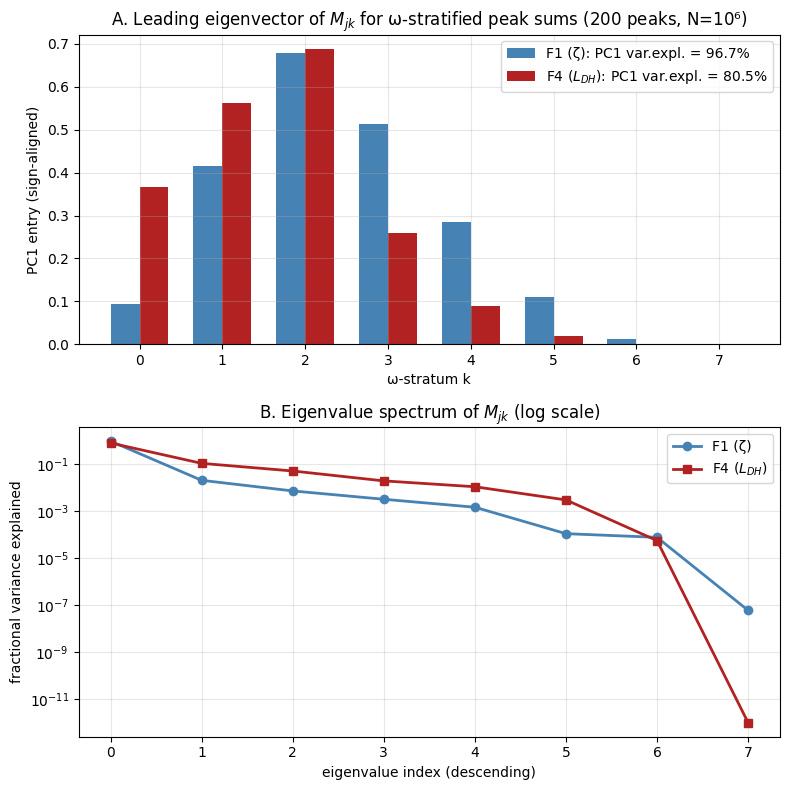

Saved figure


In [26]:
# Build summary figure
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Subfigure A: Leading eigenvector entries for F1 and F4
ax = axes[0]
k_vals = np.arange(8)
width = 0.35
ax.bar(k_vals - width/2, v1_F1, width, label=f'F1 (ζ): PC1 var.expl. = {eigvals_F1[0]/eigvals_F1.sum():.1%}', color='steelblue')
ax.bar(k_vals + width/2, v1_F4, width, label=f'F4 ($L_{{DH}}$): PC1 var.expl. = {eigvals_F4[0]/eigvals_F4.sum():.1%}', color='firebrick')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('ω-stratum k')
ax.set_ylabel('PC1 entry (sign-aligned)')
ax.set_title('A. Leading eigenvector of $M_{jk}$ for ω-stratified peak sums (200 peaks, N=10⁶)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Subfigure B: Eigenvalue spectrum
ax = axes[1]
ax.semilogy(np.arange(8), eigvals_F1/eigvals_F1.sum(), 'o-', label='F1 (ζ)', color='steelblue', lw=2)
ax.semilogy(np.arange(8), np.maximum(eigvals_F4/eigvals_F4.sum(), 1e-12), 's-', label='F4 ($L_{{DH}}$)', color='firebrick', lw=2)
ax.set_xlabel('eigenvalue index (descending)')
ax.set_ylabel('fractional variance explained')
ax.set_title('B. Eigenvalue spectrum of $M_{jk}$ (log scale)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('eigenvector_comparison.png', dpi=120)
plt.show()
print("Saved figure")


In [27]:
from e14c.filesystem import write_file
report = '''Context note for final response:
- Existing workspace files labeled generically as Sk_re.npy/Sk_im.npy/t_peaks.npy did not match the stated zeta t-range [1e4,1e5]; their t-range was [50,2000], matching the F4 task. I therefore regenerated both F1 and F4 analyses from scratch rather than trusting mislabeled intermediates.
- F1 (zeta) peak finding used a numba-accelerated Riemann-Siegel Z-function approximation with C0 correction on a 0.05 grid over [1e4,1e5], then local refinement on a 0.001 grid in ±0.05 windows.
- F4 (Davenport-Heilbronn) peak finding used a truncated Dirichlet polynomial with M=10^4 on a 0.05 grid over [50,2000], then local refinement on a 0.001 grid in ±0.05 windows.
- For both classes, ω-stratified sums S_k for k=0..7 were then computed with N=10^6 over the top 200 peaks using ω(n)=k.
- Artifacts saved: Sk_at_peaks_F4.npz, Sk_at_peaks_zeta_N1e6_regenerated.npz, eigenvector_comparison.png.
'''
write_file('analysis_summary_note.txt', report)
print('Wrote analysis_summary_note.txt')

Wrote analysis_summary_note.txt
